# Unemployment Analysis with Python — Internship Task 2
**Dataset:** Unemployment in India , **Models:** LSTM + Random Forest Regressor

## Cell 1 — Library Import

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras

import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Cell 2 — Dataset Load & Preview

In [5]:
df1 = pd.read_csv('/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment in India.csv')
df2 = pd.read_csv('/kaggle/input/datasets/gokulrajkmv/unemployment-in-india/Unemployment_Rate_upto_11_2020.csv')

df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print('File 1 shape:', df1.shape)
print('File 2 shape:', df2.shape)
print('\nFile 1 preview:')
display(df1.head())
print('\nFile 2 preview:')
display(df2.head())

File 1 shape: (768, 7)
File 2 shape: (267, 9)

File 1 preview:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



File 2 preview:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


## Cell 3 — Data Cleaning

In [6]:
# Drop null rows
df1.dropna(inplace=True)
df2.dropna(inplace=True)

# Parse dates
df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), dayfirst=True)

# Rename columns
rename_map = {
    'Estimated Unemployment Rate (%)' : 'Unemployment_Rate',
    'Estimated Employed'              : 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation_Rate'
}
df1.rename(columns=rename_map, inplace=True)
df2.rename(columns=rename_map, inplace=True)

# Strip whitespace from Region
df1['Region'] = df1['Region'].str.strip()
df2['Region'] = df2['Region'].str.strip()

print('File 1 — Null values after cleaning:')
print(df1.isnull().sum())
print('\nFile 2 — Null values after cleaning:')
print(df2.isnull().sum())
print(f'\nDate range (File 1): {df1["Date"].min().date()} → {df1["Date"].max().date()}')
print(f'Date range (File 2): {df2["Date"].min().date()} → {df2["Date"].max().date()}')

File 1 — Null values after cleaning:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Area                         0
dtype: int64

File 2 — Null values after cleaning:
Region                       0
Date                         0
Frequency                    0
Unemployment_Rate            0
Employed                     0
Labour_Participation_Rate    0
Region.1                     0
longitude                    0
latitude                     0
dtype: int64

Date range (File 1): 2019-05-31 → 2020-06-30
Date range (File 2): 2020-01-31 → 2020-10-31


## Cell 4 — EDA: Basic Statistics & Distribution

=== Statistical Summary (File 1) ===


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


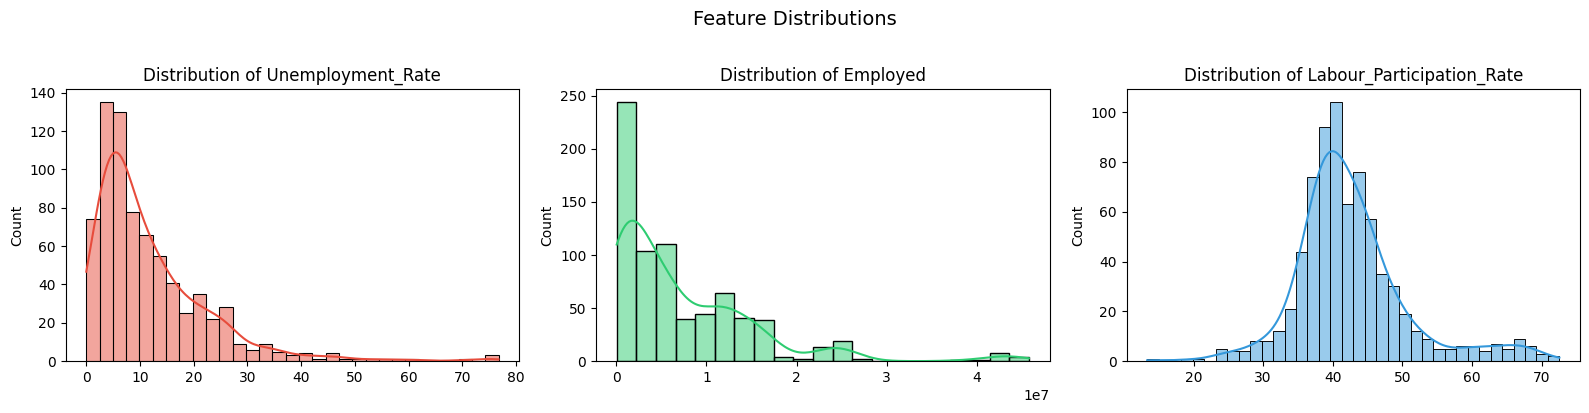

In [7]:
print('=== Statistical Summary (File 1) ===')
display(df1[['Unemployment_Rate','Employed','Labour_Participation_Rate']].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cols  = ['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']
colors = ['#e74c3c', '#2ecc71', '#3498db']

for ax, col, color in zip(axes, cols, colors):
    sns.histplot(df1[col], kde=True, ax=ax, color=color)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Cell 5 — EDA: Unemployment Rate by Region

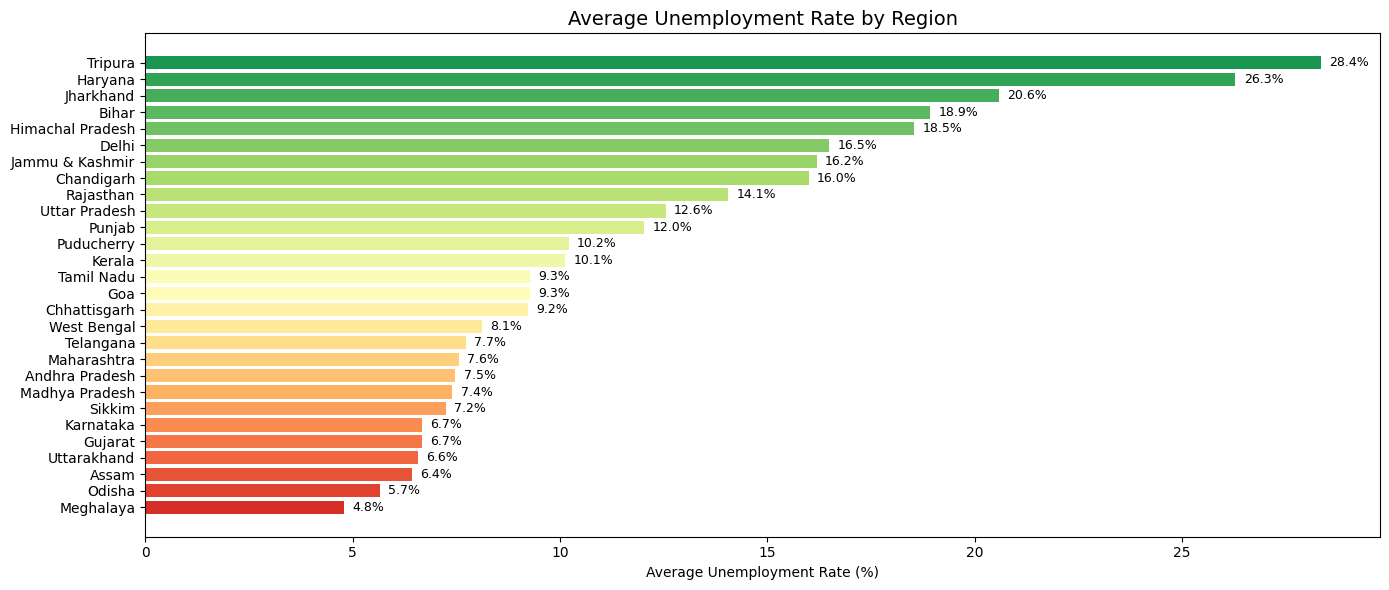

In [8]:
region_avg = df1.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.barh(region_avg.index, region_avg.values, color=plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(region_avg))))
plt.xlabel('Average Unemployment Rate (%)')
plt.title('Average Unemployment Rate by Region', fontsize=14)
plt.gca().invert_yaxis()
for bar, val in zip(bars, region_avg.values):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Cell 6 — EDA: Overall Unemployment Trend Over Time

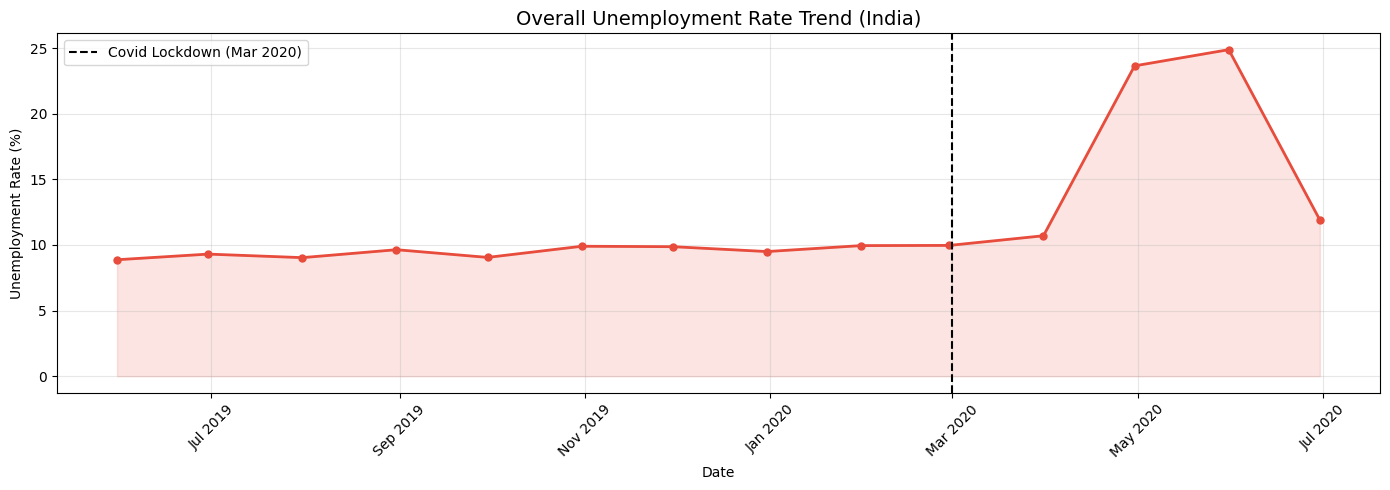

In [9]:
monthly_avg = df1.groupby('Date')['Unemployment_Rate'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], marker='o', linewidth=2, color='#e74c3c', markersize=5)
plt.axvline(pd.Timestamp('2020-03-01'), color='black', linestyle='--', linewidth=1.5, label='Covid Lockdown (Mar 2020)')
plt.fill_between(monthly_avg['Date'], monthly_avg['Unemployment_Rate'], alpha=0.15, color='#e74c3c')
plt.title('Overall Unemployment Rate Trend (India)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 7 — Covid-19 Impact Analysis

Pre-Covid  avg unemployment : 9.51%
Post-Covid avg unemployment : 17.77%
Increase                    : 8.26%


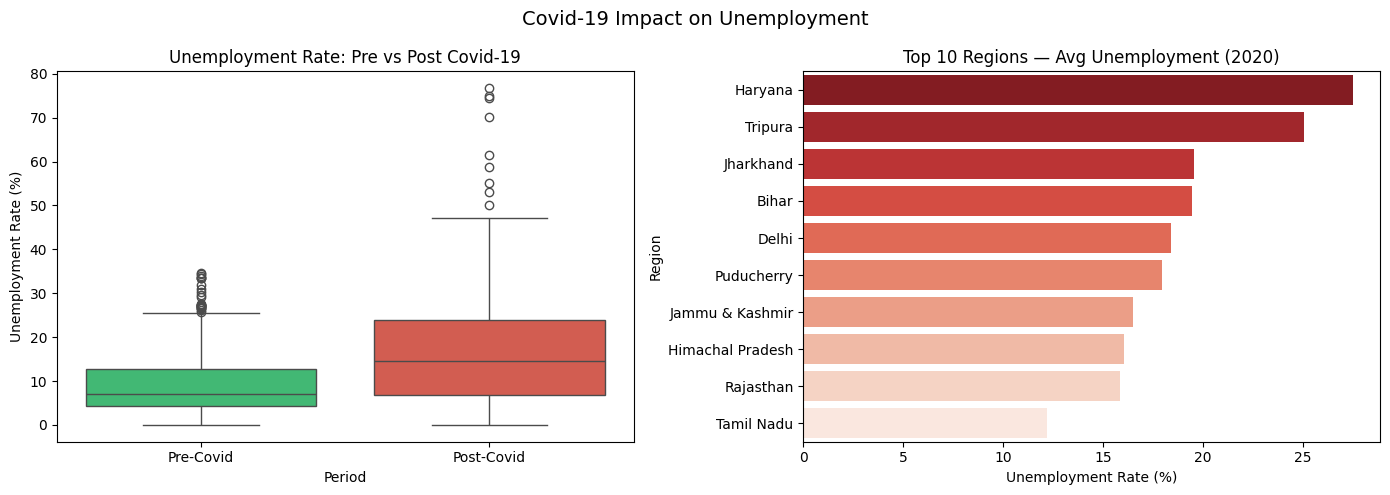

In [10]:
# Split pre-Covid vs Covid period
pre_covid  = df1[df1['Date'] < '2020-03-01']['Unemployment_Rate']
post_covid = df1[df1['Date'] >= '2020-03-01']['Unemployment_Rate']

print(f'Pre-Covid  avg unemployment : {pre_covid.mean():.2f}%')
print(f'Post-Covid avg unemployment : {post_covid.mean():.2f}%')
print(f'Increase                    : {post_covid.mean() - pre_covid.mean():.2f}%')

# Box plot comparison
df1['Period'] = df1['Date'].apply(lambda x: 'Post-Covid' if x >= pd.Timestamp('2020-03-01') else 'Pre-Covid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df1, x='Period', y='Unemployment_Rate', palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Unemployment Rate: Pre vs Post Covid-19')
axes[0].set_ylabel('Unemployment Rate (%)')

# Region-wise Covid impact using File 2 (has pre+post covid data)
covid_region = df2.groupby('Region')['Unemployment_Rate'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=covid_region.values, y=covid_region.index, palette='Reds_r', ax=axes[1])
axes[1].set_title('Top 10 Regions — Avg Unemployment (2020)')
axes[1].set_xlabel('Unemployment Rate (%)')

plt.suptitle('Covid-19 Impact on Unemployment', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 8 — Correlation Heatmap

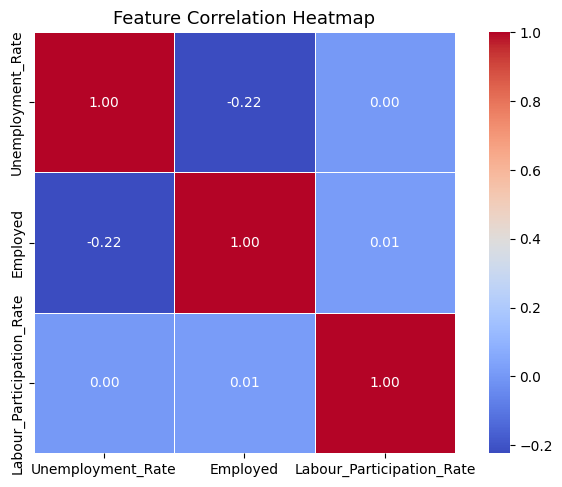

In [11]:
plt.figure(figsize=(7, 5))
corr = df1[['Unemployment_Rate', 'Employed', 'Labour_Participation_Rate']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## Cell 9 — Feature Engineering for ML Models

In [12]:
df_ml = df1.copy()

# Encode Region
le = LabelEncoder()
df_ml['Region_enc'] = le.fit_transform(df_ml['Region'])

# Encode Area if present
if 'Area' in df_ml.columns:
    df_ml['Area_enc'] = LabelEncoder().fit_transform(df_ml['Area'].str.strip())
else:
    df_ml['Area_enc'] = 0

# Date features
df_ml['Month']       = df_ml['Date'].dt.month
df_ml['Year']        = df_ml['Date'].dt.year
df_ml['Covid_Flag']  = (df_ml['Date'] >= '2020-03-01').astype(int)

features = ['Region_enc', 'Area_enc', 'Month', 'Year', 'Covid_Flag',
            'Employed', 'Labour_Participation_Rate']
target   = 'Unemployment_Rate'

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train samples : {X_train.shape[0]}')
print(f'Test samples  : {X_test.shape[0]}')
print(f'Features used : {features}')

Train samples : 592
Test samples  : 148
Features used : ['Region_enc', 'Area_enc', 'Month', 'Year', 'Covid_Flag', 'Employed', 'Labour_Participation_Rate']


## Cell 10 — Model 1: Random Forest Regressor

=== Random Forest — Test Data Results ===
MAE  : 3.9443
RMSE : 7.2104
R²   : 0.6409


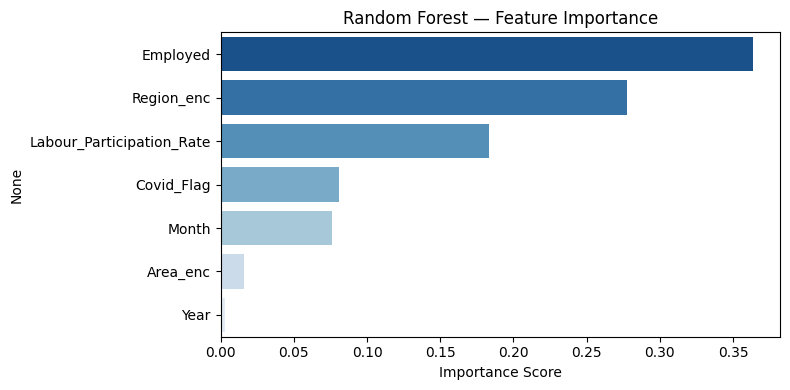

In [13]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)

print('=== Random Forest — Test Data Results ===')
print(f'MAE  : {rf_mae:.4f}')
print(f'RMSE : {rf_rmse:.4f}')
print(f'R²   : {rf_r2:.4f}')

# Feature Importance
importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=importance.values, y=importance.index, palette='Blues_r')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Cell 11 — Model 2: LSTM Neural Network (with Epochs)

In [14]:
# Scale features for LSTM
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_sc  = scaler_y.transform(y_test.values.reshape(-1, 1))

# Reshape for LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_sc.reshape((X_train_sc.shape[0], 1, X_train_sc.shape[1]))
X_test_lstm  = X_test_sc.reshape((X_test_sc.shape[0],  1, X_test_sc.shape[1]))

# Build LSTM model
lstm_model = keras.Sequential([
    keras.layers.LSTM(64, return_sequences=True, input_shape=(1, X_train_sc.shape[1])),
    keras.layers.LSTM(32),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

I0000 00:00:1779360627.256948      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

## Cell 12 — LSTM: Train with Validation Data (Epochs)

In [15]:
history = lstm_model.fit(
    X_train_lstm, y_train_sc,
    epochs=60,
    batch_size=16,
    validation_data=(X_test_lstm, y_test_sc),
    verbose=1
)

print(f'\nFinal Train Loss : {history.history["loss"][-1]:.4f}')
print(f'Final Test  Loss : {history.history["val_loss"][-1]:.4f}')

Epoch 1/60


I0000 00:00:1779360630.990715     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0267 - mae: 0.1163 - val_loss: 0.0224 - val_mae: 0.1065
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0160 - mae: 0.0924 - val_loss: 0.0211 - val_mae: 0.1007
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0157 - mae: 0.0917 - val_loss: 0.0205 - val_mae: 0.0979
Epoch 4/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0155 - mae: 0.0909 - val_loss: 0.0202 - val_mae: 0.0967
Epoch 5/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0154 - mae: 0.0904 - val_loss: 0.0201 - val_mae: 0.0961
Epoch 6/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0153 - mae: 0.0901 - val_loss: 0.0200 - val_mae: 0.0959
Epoch 7/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0152 - mae: 0.0899 - val_loss: 0.0200 - val_mae: 0.0958
Epoch 8/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0151 - mae: 0.0898 - val_loss: 0.0200 - val_mae: 0.0957
Epoch 9/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0150 - mae: 0.0895 - v

## Cell 13 — LSTM: Accuracy & Loss Curve (Train vs Test)

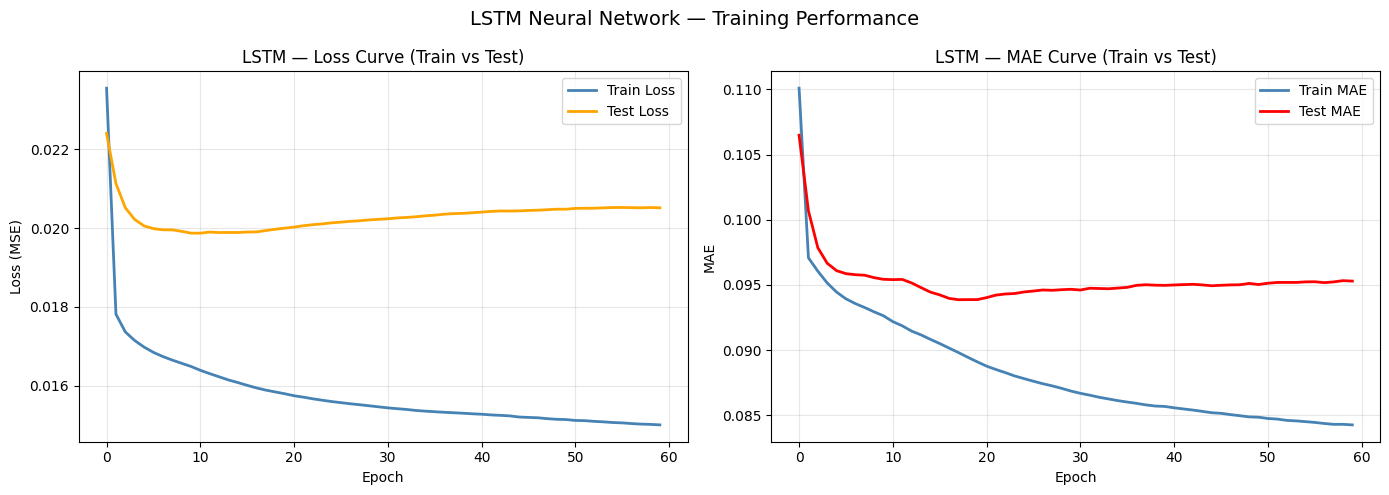

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Test Loss',  color='orange',    linewidth=2)
ax1.set_title('LSTM — Loss Curve (Train vs Test)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['mae'],     label='Train MAE', color='steelblue', linewidth=2)
ax2.plot(history.history['val_mae'], label='Test MAE',  color='red',       linewidth=2)
ax2.set_title('LSTM — MAE Curve (Train vs Test)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('LSTM Neural Network — Training Performance', fontsize=14)
plt.tight_layout()
plt.show()

## Cell 14 — LSTM: Evaluate on Test Data

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
=== LSTM — Test Data Results ===
MAE  : 7.1467
RMSE : 10.7422
R²   : 0.2030


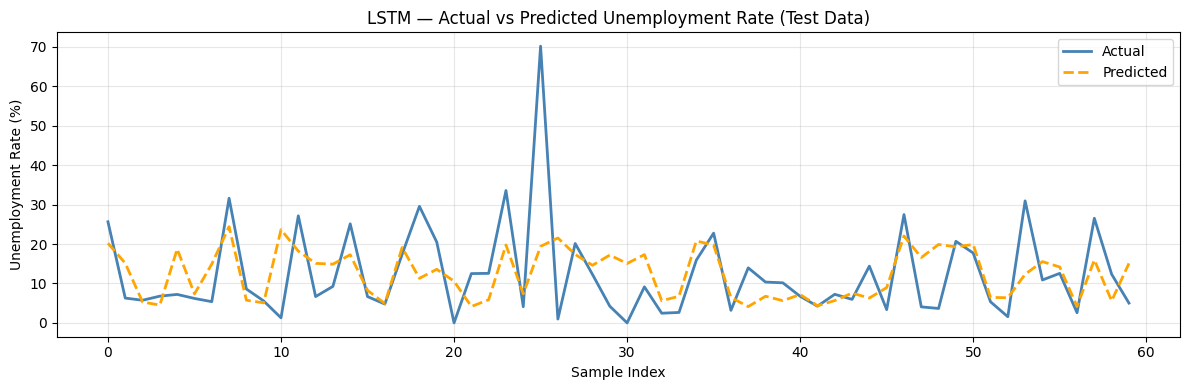

In [17]:
y_pred_lstm_sc = lstm_model.predict(X_test_lstm)
y_pred_lstm    = scaler_y.inverse_transform(y_pred_lstm_sc).flatten()

lstm_mae  = mean_absolute_error(y_test, y_pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
lstm_r2   = r2_score(y_test, y_pred_lstm)

print('=== LSTM — Test Data Results ===')
print(f'MAE  : {lstm_mae:.4f}')
print(f'RMSE : {lstm_rmse:.4f}')
print(f'R²   : {lstm_r2:.4f}')

# Actual vs Predicted plot
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:60], label='Actual',    color='steelblue', linewidth=2)
plt.plot(y_pred_lstm[:60],   label='Predicted', color='orange',    linewidth=2, linestyle='--')
plt.title('LSTM — Actual vs Predicted Unemployment Rate (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Cell 15 — Final Model Comparison


       FINAL MODEL COMPARISON (Test Data)  
              Model    MAE    RMSE     R²
      Random Forest 3.9443  7.2104 0.6409
LSTM Neural Network 7.1467 10.7422 0.2030
Higher R² = Better | Lower MAE/RMSE = Better


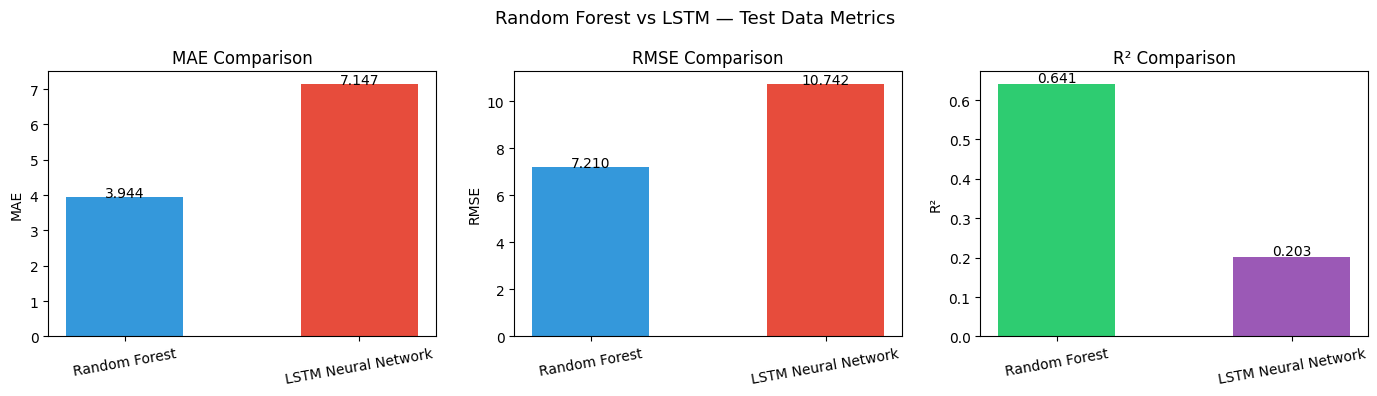


=== KEY INSIGHTS ===
1. Covid-19 caused a sharp spike in unemployment around April-May 2020.
2. Some regions were hit significantly harder than others during lockdown.
3. Labour Participation Rate dropped alongside rising unemployment.
4. Unemployment showed a gradual recovery trend post mid-2020.


In [18]:
results = pd.DataFrame({
    'Model' : ['Random Forest', 'LSTM Neural Network'],
    'MAE'   : [round(rf_mae,  4), round(lstm_mae,  4)],
    'RMSE'  : [round(rf_rmse, 4), round(lstm_rmse, 4)],
    'R²'    : [round(rf_r2,   4), round(lstm_r2,   4)]
})

print('\n============================================')
print('       FINAL MODEL COMPARISON (Test Data)  ')
print('============================================')
print(results.to_string(index=False))
print('============================================')
print('Higher R² = Better | Lower MAE/RMSE = Better')

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'RMSE', 'R²']
colors  = [['#3498db','#e74c3c'], ['#3498db','#e74c3c'], ['#2ecc71','#9b59b6']]

for ax, metric, color in zip(axes, metrics, colors):
    vals = results[metric].values
    bars = ax.bar(results['Model'], vals, color=color, width=0.5)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Random Forest vs LSTM — Test Data Metrics', fontsize=13)
plt.tight_layout()
plt.show()

# Key Insights
print('\n=== KEY INSIGHTS ===')
print('1. Covid-19 caused a sharp spike in unemployment around April-May 2020.')
print('2. Some regions were hit significantly harder than others during lockdown.')
print('3. Labour Participation Rate dropped alongside rising unemployment.')
print('4. Unemployment showed a gradual recovery trend post mid-2020.')